# Uber Trip Analysis — Advanced ML Project
**Tools:** Python, XGBoost, Scikit-learn, Statsmodels, Chart.js  
**Domain:** Data Analyst / Data Scientist  
**Level:** Advanced

---
### Project Roadmap
1. Install & Import Libraries
2. Load & Merge Dataset
3. Data Preprocessing
4. Exploratory Data Analysis (EDA)
5. Time Series Analysis & Decomposition
6. Feature Engineering (Lagged Windows)
7. Train/Test Split
8. ML Models — XGBoost, Random Forest, GBRT
9. Ensemble Model
10. Model Comparison
11. Interactive Dashboard

## Step 1: Install & Import Libraries

In [5]:
!pip install xgboost statsmodels --quiet

import warnings
warnings.filterwarnings('ignore')

import io
import json
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import HTML
from google.colab import files

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
%matplotlib inline

print('✅ All libraries imported!')

✅ All libraries imported!


## Step 2: Load  Dataset

In [21]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

base_map = {
    'B02512': 'Unter',
    'B02598': 'Hinter',
    'B02617': 'Weiter',
    'B02682': 'Schmecken',
    'B02764': 'Danach-NY',
    'B02765': 'Grun'
}
df['base_name'] = df['dispatching_base_number'].map(base_map)

print(f"✅ Loaded! Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

Saving Uber-Jan-Feb-FOIL.csv to Uber-Jan-Feb-FOIL (1).csv
✅ Loaded! Shape: (354, 5)
Date range: 2015-01-01 → 2015-02-28


,dispatching_base_number,date,active_vehicles,trips,base_name
0,B02512,2015-01-01,190,1132,Unter
1,B02765,2015-01-01,225,1765,Grun
2,B02764,2015-01-01,3427,29421,Danach-NY
3,B02682,2015-01-01,945,7679,Schmecken
4,B02617,2015-01-01,1228,9537,Weiter


In [22]:
df.head()

,dispatching_base_number,date,active_vehicles,trips,base_name
0,B02512,2015-01-01,190,1132,Unter
1,B02765,2015-01-01,225,1765,Grun
2,B02764,2015-01-01,3427,29421,Danach-NY
3,B02682,2015-01-01,945,7679,Schmecken
4,B02617,2015-01-01,1228,9537,Weiter


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB


In [12]:
df.columns

Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips'], dtype='object')

## Step 3: Data Preprocessing

In [23]:
df['day_name']        = df['date'].dt.day_name()
df['day_num']         = df['date'].dt.dayofweek
df['day']             = df['date'].dt.day
df['month']           = df['date'].dt.month
df['trips_per_vehicle'] = (df['trips'] / df['active_vehicles']).round(2)

print("✅ Features added!")
df[['date','base_name','active_vehicles','trips','trips_per_vehicle']].head(8)

✅ Features added!


,date,base_name,active_vehicles,trips,trips_per_vehicle
0,2015-01-01,Unter,190,1132,5.96
1,2015-01-01,Grun,225,1765,7.84
2,2015-01-01,Danach-NY,3427,29421,8.59
3,2015-01-01,Schmecken,945,7679,8.13
4,2015-01-01,Weiter,1228,9537,7.77
5,2015-01-01,Hinter,870,6903,7.93
6,2015-01-02,Danach-NY,3147,19974,6.35
7,2015-01-02,Grun,196,1001,5.11


## Step 4: EDA: Total Trips by Base

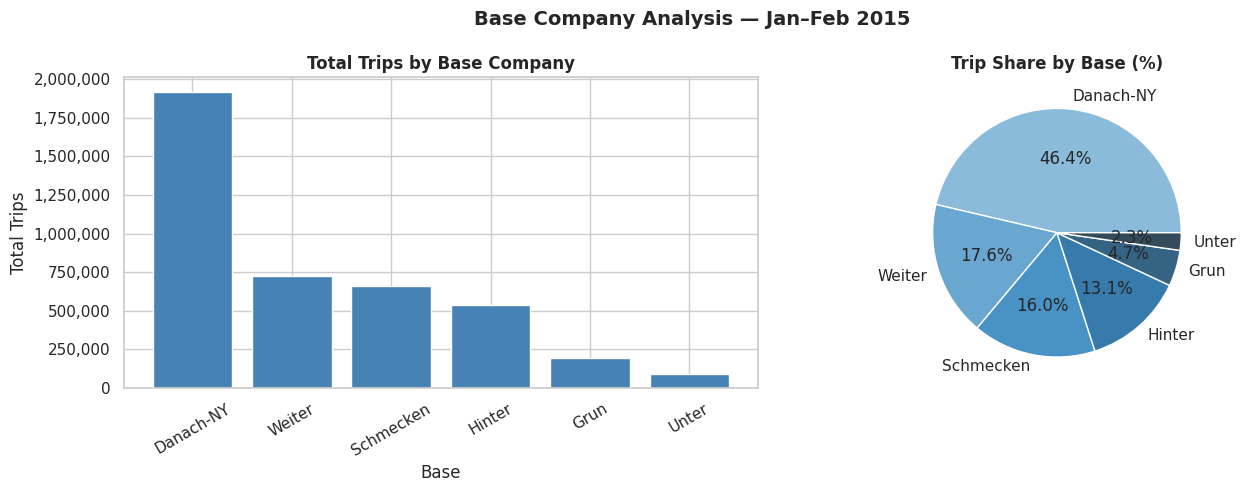

In [24]:
base_totals = df.groupby('base_name')['trips'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(base_totals['base_name'], base_totals['trips'], color='steelblue', edgecolor='white')
axes[0].set_title('Total Trips by Base Company', fontweight='bold')
axes[0].set_xlabel('Base')
axes[0].set_ylabel('Total Trips')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].pie(base_totals['trips'], labels=base_totals['base_name'],
            autopct='%1.1f%%', colors=sns.color_palette('Blues_d', len(base_totals)))
axes[1].set_title('Trip Share by Base (%)', fontweight='bold')

plt.suptitle('Base Company Analysis — Jan–Feb 2015', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5:EDA: Trips by Day of Week

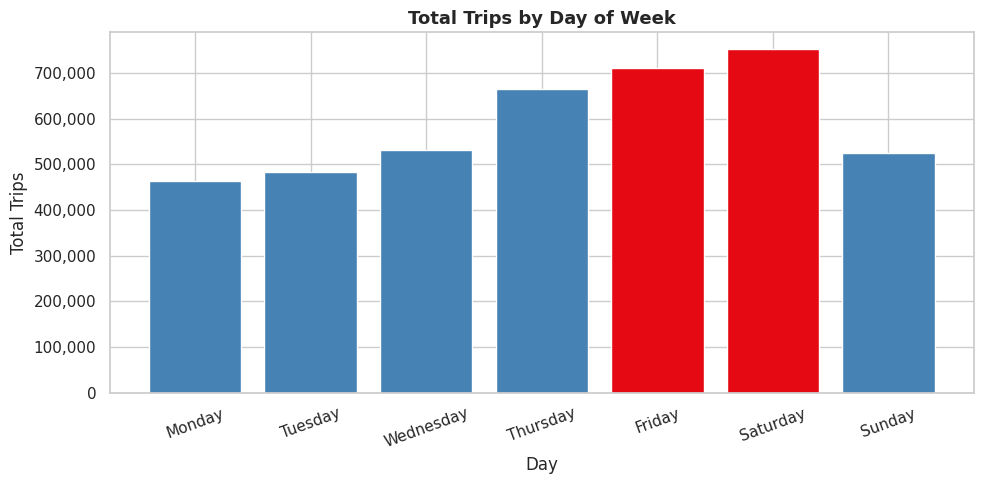

In [25]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_name')['trips'].sum().reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))
colors = ['#E50914' if d in ['Friday','Saturday'] else 'steelblue' for d in dow['day_name']]
bars = plt.bar(dow['day_name'], dow['trips'], color=colors, edgecolor='white')
plt.title('Total Trips by Day of Week', fontweight='bold', fontsize=13)
plt.xlabel('Day')
plt.ylabel('Total Trips')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.show()

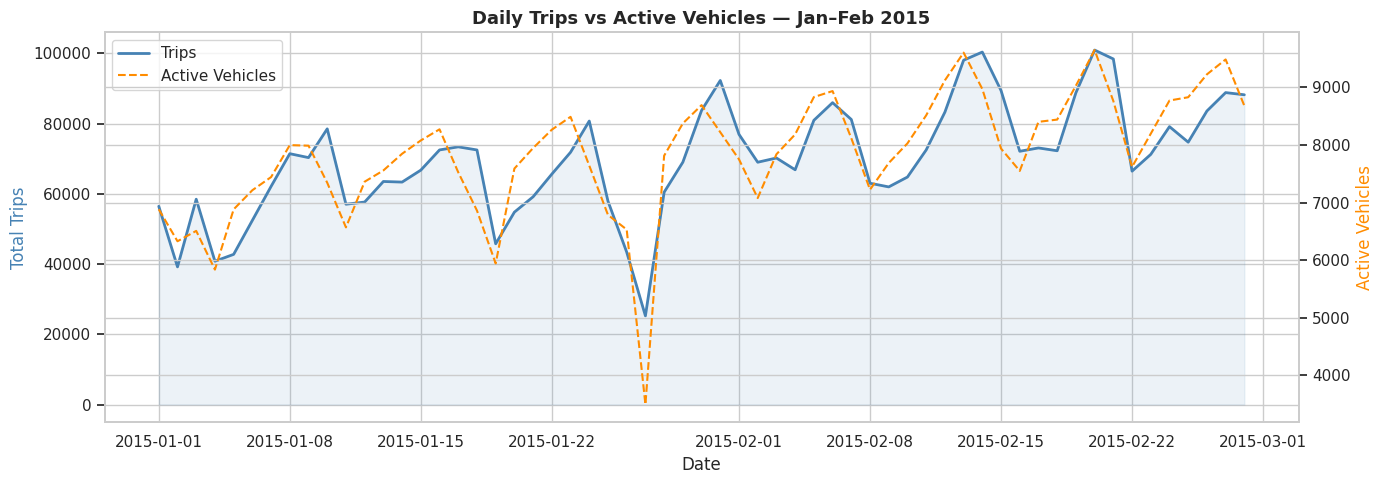

In [26]:
# EDA: Daily Trips + Active Vehicles trend
daily = df.groupby('date').agg(
    total_trips=('trips', 'sum'),
    total_vehicles=('active_vehicles', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(daily['date'], daily['total_trips'], color='steelblue', lw=2, label='Trips')
ax1.fill_between(daily['date'], daily['total_trips'], alpha=0.1, color='steelblue')
ax2.plot(daily['date'], daily['total_vehicles'], color='darkorange', lw=1.5, linestyle='--', label='Active Vehicles')

ax1.set_xlabel('Date')
ax1.set_ylabel('Total Trips', color='steelblue')
ax2.set_ylabel('Active Vehicles', color='darkorange')
ax1.set_title('Daily Trips vs Active Vehicles — Jan–Feb 2015', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

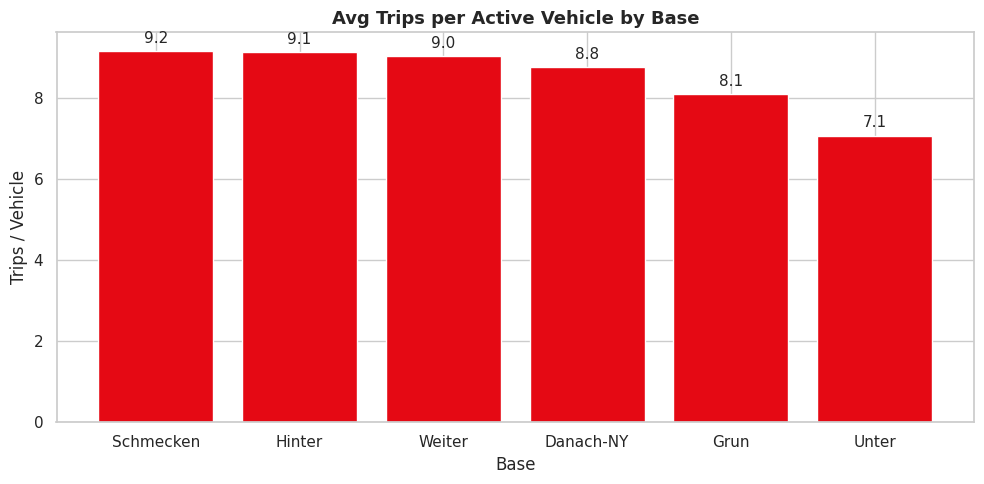

In [27]:
# EDA: Trips per Vehicle (efficiency)
eff = df.groupby('base_name')['trips_per_vehicle'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(eff['base_name'], eff['trips_per_vehicle'], color='#E50914', edgecolor='white')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', fontsize=11)
plt.title('Avg Trips per Active Vehicle by Base', fontsize=13, fontweight='bold')
plt.xlabel('Base')
plt.ylabel('Trips / Vehicle')
plt.tight_layout()
plt.show()

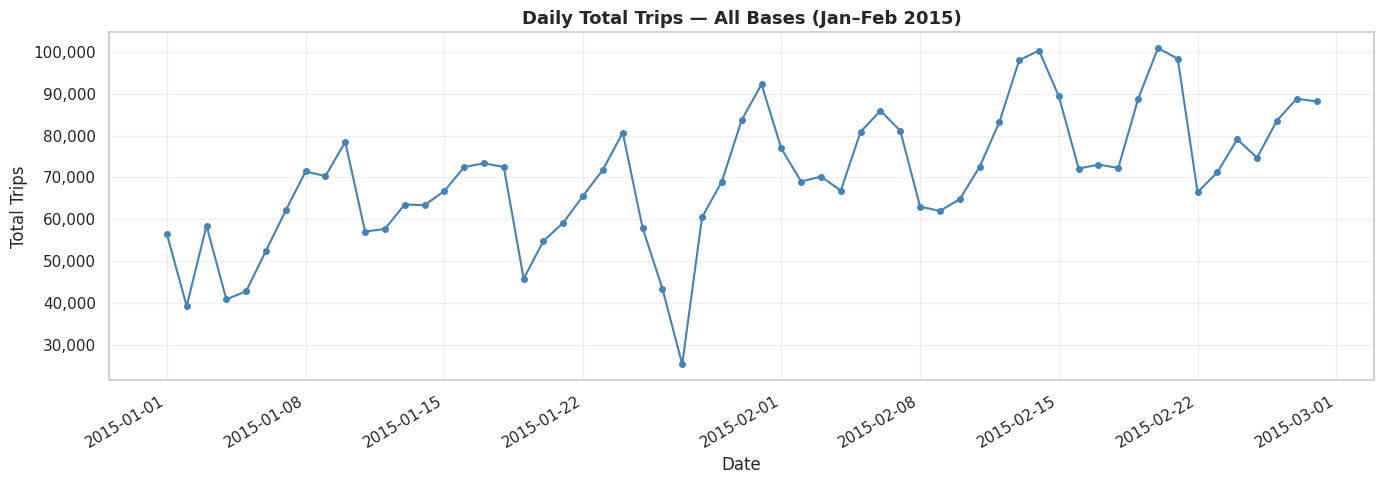

Total days   : 59
Avg per day  : 70,004
Max day      : 2015-02-20 — 100,915 trips
Min day      : 2015-01-27 — 25,244 trips


In [28]:
#Time Series: Daily total trips
ts = df.groupby('date')['trips'].sum().reset_index()
ts.columns = ['Date', 'Count']
ts = ts.set_index('Date')

plt.figure(figsize=(14, 5))
plt.plot(ts['Count'], lw=1.5, color='steelblue', marker='o', markersize=4)
plt.title('Daily Total Trips — All Bases (Jan–Feb 2015)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Trips')
plt.xticks(rotation=30, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total days   : {len(ts)}")
print(f"Avg per day  : {ts['Count'].mean():,.0f}")
print(f"Max day      : {ts['Count'].idxmax().date()} — {ts['Count'].max():,} trips")
print(f"Min day      : {ts['Count'].idxmin().date()} — {ts['Count'].min():,} trips")

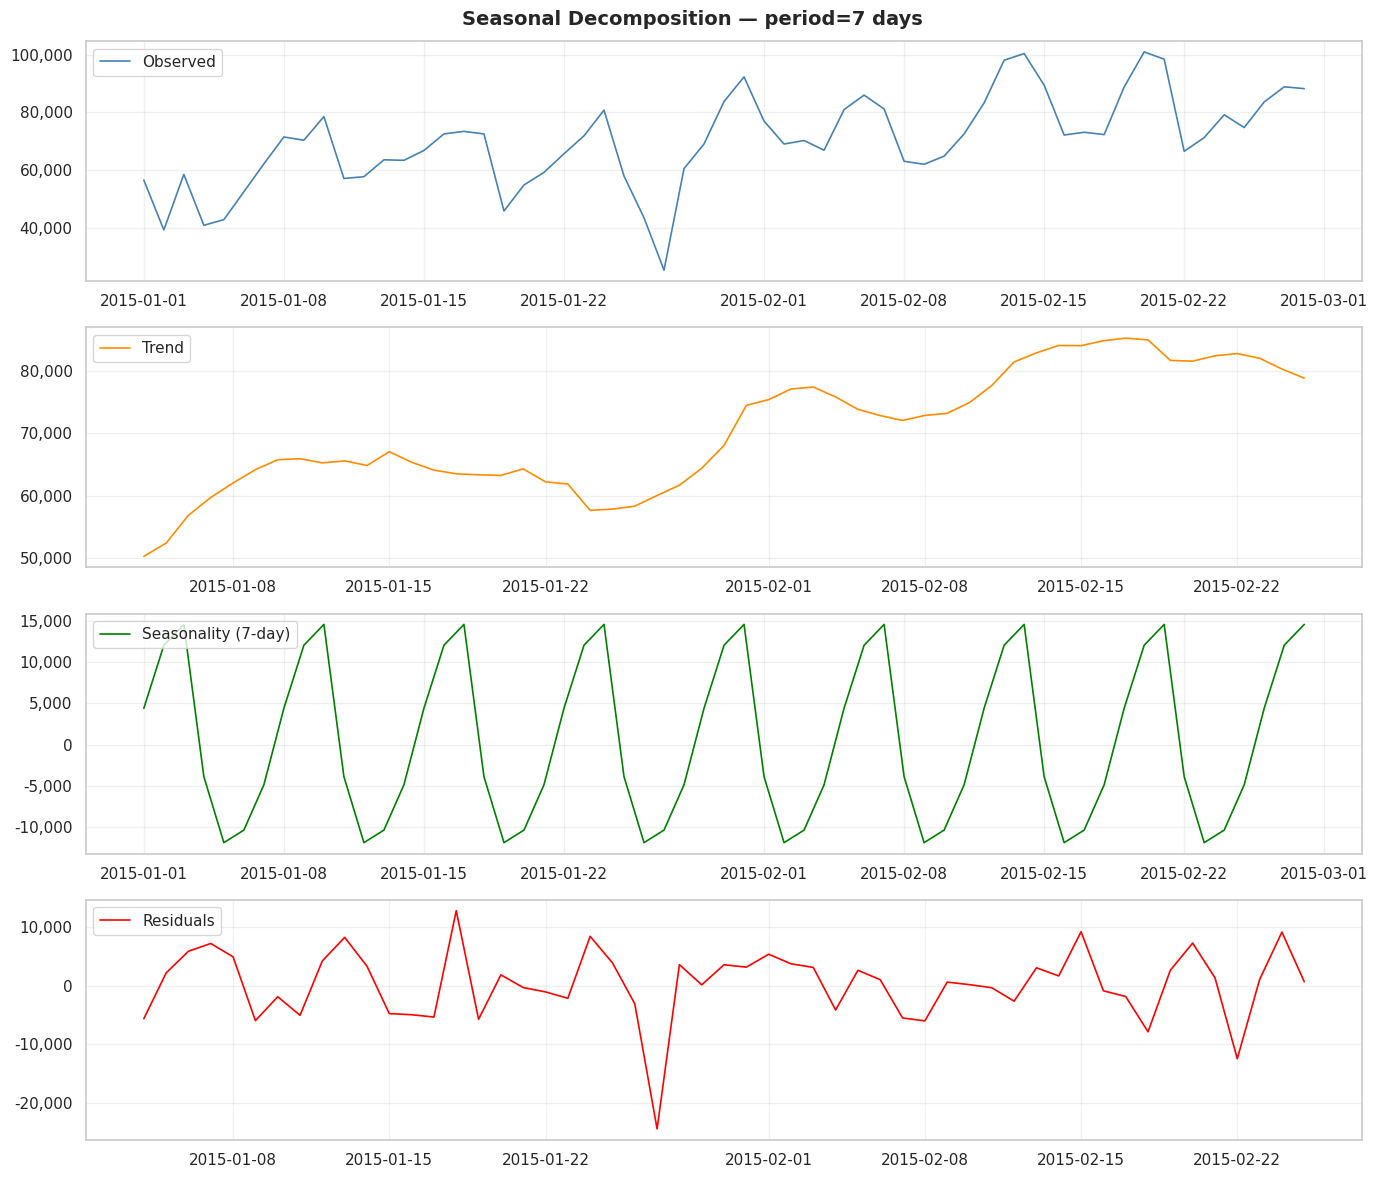

In [29]:
# Seasonal Decomposition
result = seasonal_decompose(ts['Count'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
components = [result.observed, result.trend, result.seasonal, result.resid]
labels_    = ['Observed', 'Trend', 'Seasonality (7-day)', 'Residuals']
colors_    = ['steelblue', 'darkorange', 'green', 'red']

for ax, comp, lbl, col in zip(axes, components, labels_, colors_):
    ax.plot(comp, lw=1.2, color=col, label=lbl)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Seasonal Decomposition — period=7 days', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Train: 48 days  |  Test: 12 days  |  Cutoff: 2015-02-17


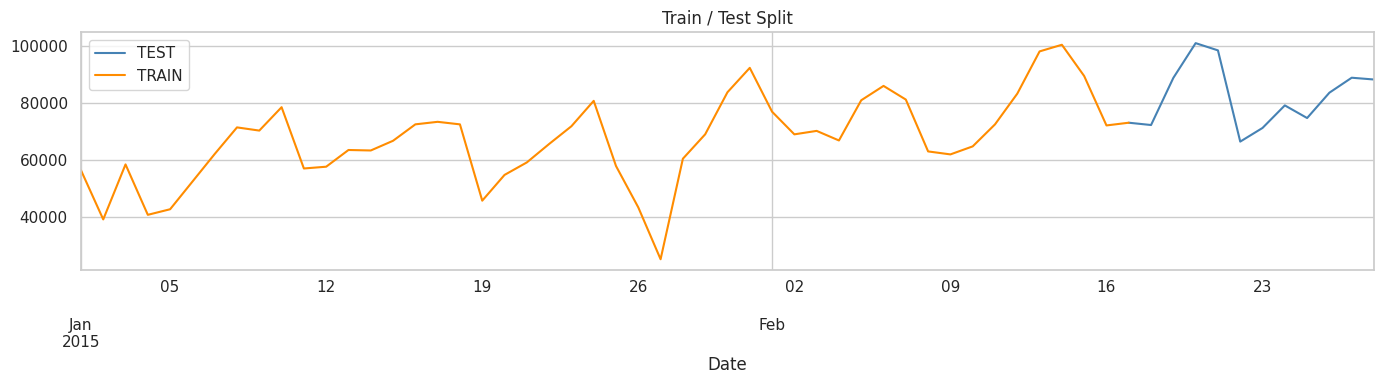

X_train: (41, 7)  |  X_test: (12, 7)


In [30]:
# Train/Test Split + Lagged Features
def create_lagged_features(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

def plot_pred(plots, title):
    plt.figure(figsize=(14, 5))
    for p in plots:
        plt.plot(p[0], p[1], label=p[2], linestyle=p[3], color=p[4], lw=1.8)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Date'); plt.ylabel('Trips')
    plt.legend(); plt.xticks(rotation=30, ha='right')
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

WINDOW = 7
SEED   = 42
n      = len(ts)
cutoff = ts.index[int(n * 0.80)]

ts_train = ts.loc[:cutoff]
ts_test  = ts.loc[cutoff:]

print(f"Train: {len(ts_train)} days  |  Test: {len(ts_test)} days  |  Cutoff: {cutoff.date()}")

ts_test.rename(columns={'Count':'TEST'}).join(
    ts_train.rename(columns={'Count':'TRAIN'}), how='outer'
).plot(figsize=(14, 4), title='Train / Test Split', lw=1.5, color=['steelblue','darkorange'])
plt.tight_layout(); plt.show()

X_train, y_train = create_lagged_features(ts_train['Count'].values, WINDOW)
test_seq          = np.concatenate([ts_train['Count'].values[-WINDOW:], ts_test['Count'].values])
X_test,  y_test  = create_lagged_features(test_seq, WINDOW)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

⏳ Training XGBoost...
✅ XGBoost MAPE : 9.67%
   Best params  : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


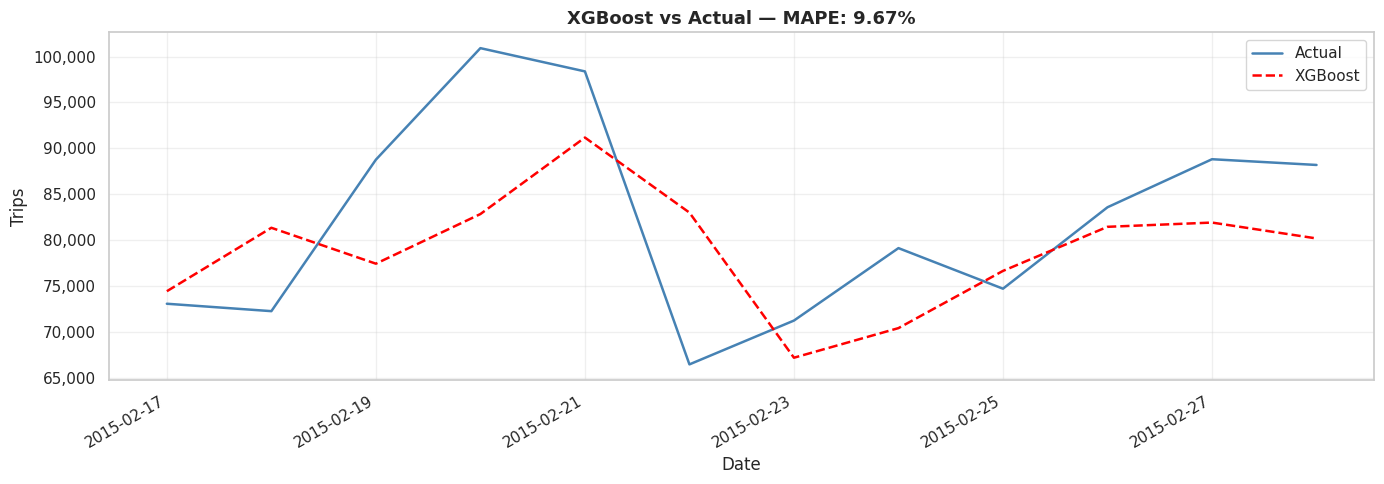

In [31]:
# XGBoost
tscv = TimeSeriesSplit(n_splits=3)

print("⏳ Training XGBoost...")
xgb_gs = GridSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=SEED),
    {'n_estimators':[100,200], 'max_depth':[3,5],
     'learning_rate':[0.05,0.1], 'subsample':[0.8,1.0]},
    cv=tscv, scoring='neg_mean_absolute_percentage_error', n_jobs=-1
)
xgb_gs.fit(X_train, y_train)
xgb_pred = xgb_gs.best_estimator_.predict(X_test)
xgb_mape = mean_absolute_percentage_error(ts_test['Count'], xgb_pred)

print(f"✅ XGBoost MAPE : {xgb_mape:.2%}")
print(f"   Best params  : {xgb_gs.best_params_}")

plot_pred([
    (ts_test.index, ts_test['Count'], 'Actual',  '-',  'steelblue'),
    (ts_test.index, xgb_pred,         'XGBoost', '--', 'red')
], f'XGBoost vs Actual — MAPE: {xgb_mape:.2%}')

⏳ Training Random Forest...
✅ Random Forest MAPE : 7.61%
   Best params        : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


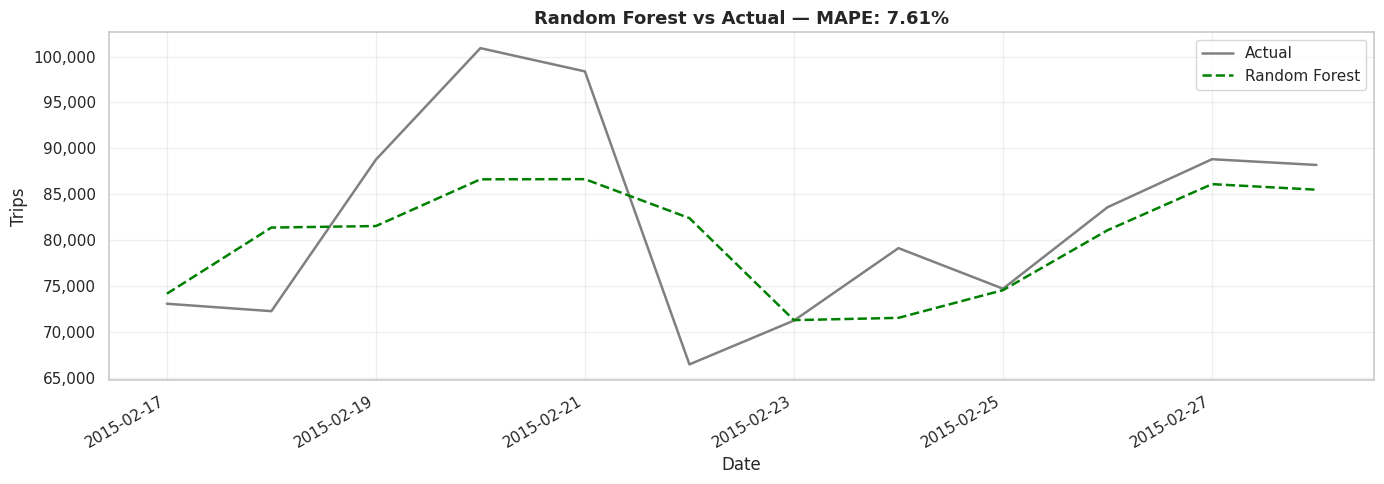

In [32]:
#Random Forest
print("⏳ Training Random Forest...")
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    {'n_estimators':[100,200], 'max_depth':[5,10,None], 'min_samples_split':[2,5]},
    cv=tscv, scoring='neg_mean_absolute_percentage_error', n_jobs=-1
)
rf_gs.fit(X_train, y_train)
rf_pred  = rf_gs.best_estimator_.predict(X_test)
rf_mape  = mean_absolute_percentage_error(ts_test['Count'], rf_pred)

print(f"✅ Random Forest MAPE : {rf_mape:.2%}")
print(f"   Best params        : {rf_gs.best_params_}")

plot_pred([
    (ts_test.index, ts_test['Count'], 'Actual',        '-',  'gray'),
    (ts_test.index, rf_pred,          'Random Forest', '--', 'green')
], f'Random Forest vs Actual — MAPE: {rf_mape:.2%}')

⏳ Training GBRT...
✅ GBRT MAPE  : 8.90%
   Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


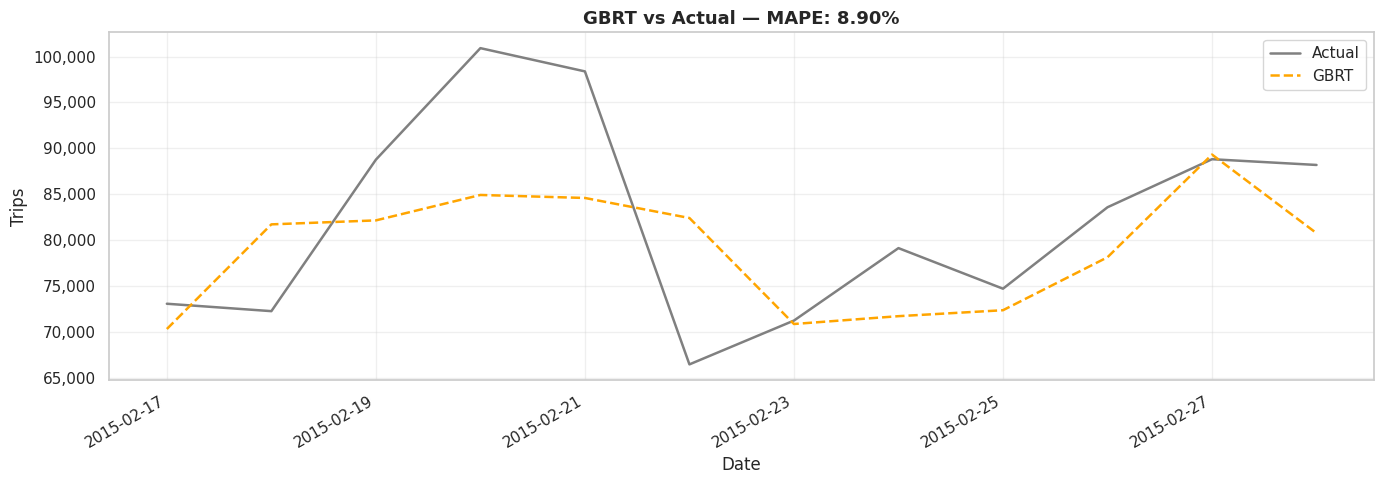

In [33]:
# GBRT
print("⏳ Training GBRT...")
gbr_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    {'n_estimators':[100,200], 'learning_rate':[0.05,0.1], 'max_depth':[3,5]},
    cv=tscv, scoring='neg_mean_absolute_percentage_error', n_jobs=-1
)
gbr_gs.fit(X_train, y_train)
gbr_pred  = gbr_gs.best_estimator_.predict(X_test)
gbr_mape  = mean_absolute_percentage_error(ts_test['Count'], gbr_pred)

print(f"✅ GBRT MAPE  : {gbr_mape:.2%}")
print(f"   Best params: {gbr_gs.best_params_}")

plot_pred([
    (ts_test.index, ts_test['Count'], 'Actual', '-',  'gray'),
    (ts_test.index, gbr_pred,         'GBRT',   '--', 'orange')
], f'GBRT vs Actual — MAPE: {gbr_mape:.2%}')

Weights — XGBoost: 0.298 | RF: 0.378 | GBRT: 0.324
✅ Ensemble MAPE: 8.29%


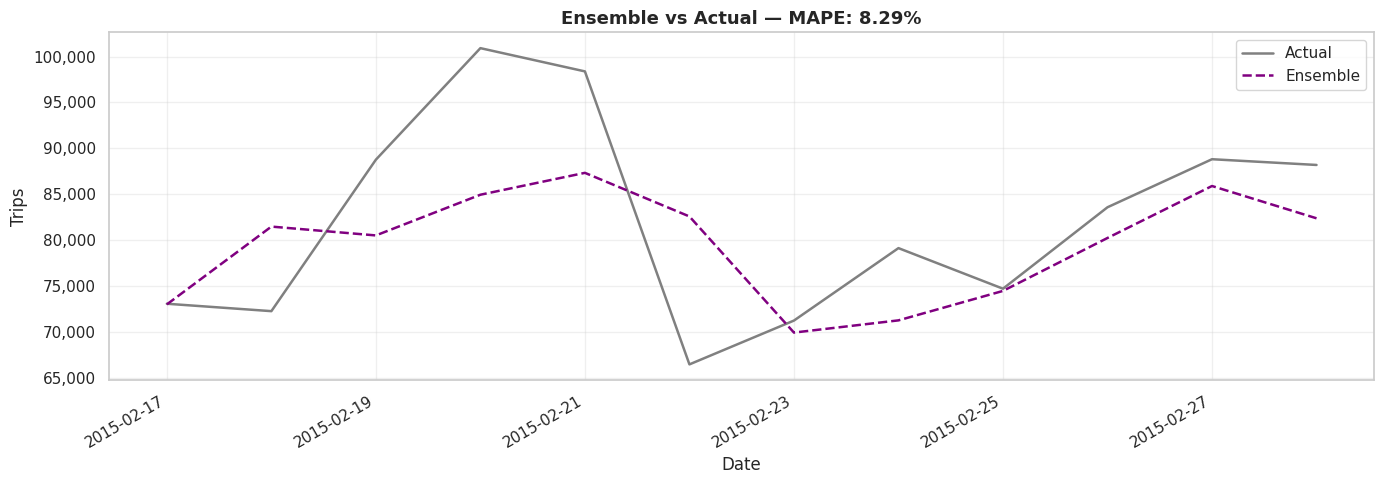

In [34]:
#  Ensemble
w_xgb = (1/xgb_mape); w_rf = (1/rf_mape); w_gbr = (1/gbr_mape)
total  = w_xgb + w_rf + w_gbr
w_xgb /= total; w_rf /= total; w_gbr /= total

ens_pred = w_xgb*xgb_pred + w_rf*rf_pred + w_gbr*gbr_pred
ens_mape = mean_absolute_percentage_error(ts_test['Count'], ens_pred)

print(f"Weights — XGBoost: {w_xgb:.3f} | RF: {w_rf:.3f} | GBRT: {w_gbr:.3f}")
print(f"✅ Ensemble MAPE: {ens_mape:.2%}")

plot_pred([
    (ts_test.index, ts_test['Count'], 'Actual',   '-',  'gray'),
    (ts_test.index, ens_pred,         'Ensemble', '--', 'purple')
], f'Ensemble vs Actual — MAPE: {ens_mape:.2%}')

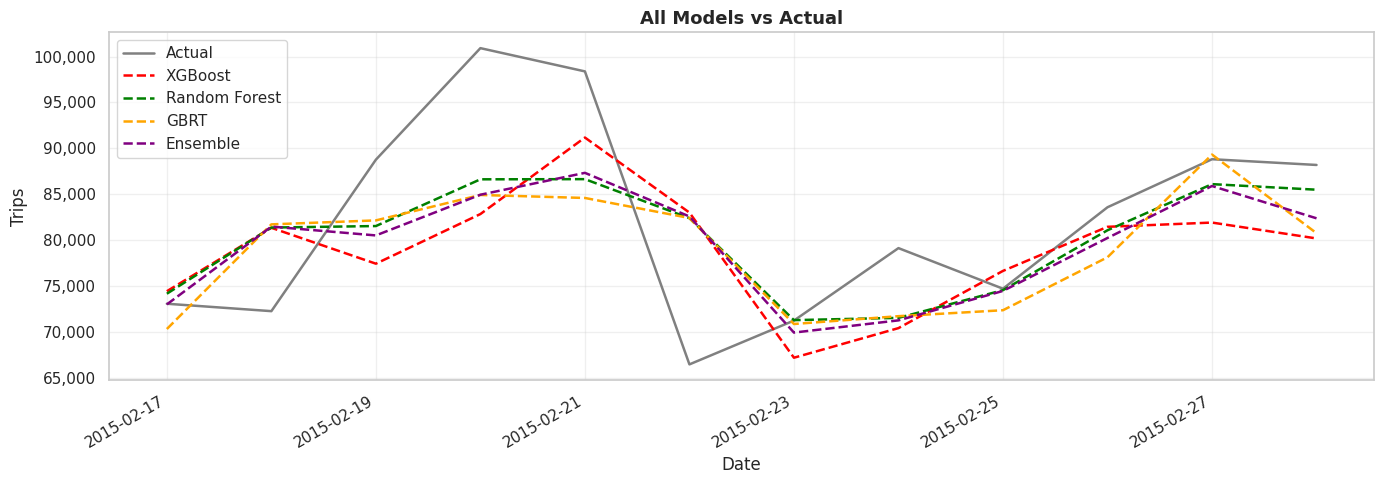

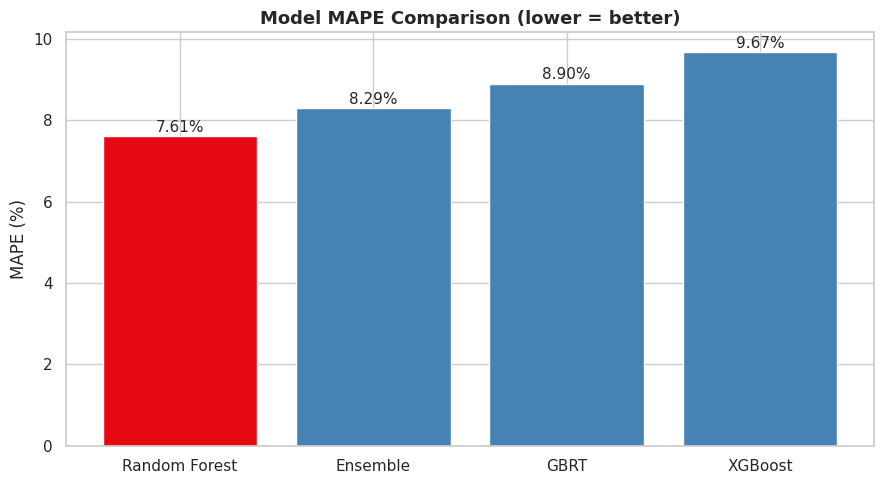


📊 Final Results:
        Model     MAPE
Random Forest 0.076146
     Ensemble 0.082935
         GBRT 0.089002
      XGBoost 0.096749


In [35]:
# Final comparison
# All models together
plot_pred([
    (ts_test.index, ts_test['Count'], 'Actual',        '-',  'gray'),
    (ts_test.index, xgb_pred,         'XGBoost',        '--', 'red'),
    (ts_test.index, rf_pred,          'Random Forest',  '--', 'green'),
    (ts_test.index, gbr_pred,         'GBRT',           '--', 'orange'),
    (ts_test.index, ens_pred,         'Ensemble',       '--', 'purple')
], 'All Models vs Actual')

# MAPE bar chart
results = pd.DataFrame({
    'Model': ['XGBoost','Random Forest','GBRT','Ensemble'],
    'MAPE':  [xgb_mape, rf_mape, gbr_mape, ens_mape]
}).sort_values('MAPE').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#E50914' if i==0 else 'steelblue' for i in range(4)]
bars = ax.bar(results['Model'], results['MAPE']*100, color=bar_colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{bar.get_height():.2f}%', ha='center', fontsize=11)
ax.set_title('Model MAPE Comparison (lower = better)', fontsize=13, fontweight='bold')
ax.set_ylabel('MAPE (%)')
plt.tight_layout()
plt.show()

print("\n📊 Final Results:")
print(results.to_string(index=False))

## Dashboard

In [37]:
# ── Prepare all data for dashboard ───────────────────────────
base_totals2  = df.groupby('base_name')['trips'].sum().sort_values(ascending=False)
b_labels      = json.dumps(base_totals2.index.tolist())
b_vals        = json.dumps(base_totals2.values.tolist())

day_order2    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow2          = df.groupby('day_name')['trips'].sum().reindex(day_order2).fillna(0)
d_labels      = json.dumps(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
d_vals        = json.dumps(dow2.astype(int).tolist())

eff2          = df.groupby('base_name')['trips_per_vehicle'].mean().sort_values(ascending=False)
e_labels      = json.dumps(eff2.index.tolist())
e_vals        = json.dumps([round(v,2) for v in eff2.values.tolist()])

ts_labels     = json.dumps([str(d.date()) for d in ts.index])
ts_actual     = json.dumps(ts['Count'].tolist())
ts_test_vals  = json.dumps([None]*(len(ts)-len(ts_test)) + ts_test['Count'].tolist())
ts_xgb        = json.dumps([None]*(len(ts)-len(ts_test)) + [round(v) for v in xgb_pred.tolist()])
ts_ens        = json.dumps([None]*(len(ts)-len(ts_test)) + [round(v) for v in ens_pred.tolist()])

mape_labels   = json.dumps(results['Model'].tolist())
mape_vals     = json.dumps([round(v*100,2) for v in results['MAPE'].tolist()])

total_trips   = int(df['trips'].sum())
total_vehicles= int(df['active_vehicles'].sum())
best_base     = base_totals2.idxmax()
best_day      = dow2.idxmax()
best_model_nm = results.iloc[0]['Model']
best_mape_val = results.iloc[0]['MAPE']
avg_daily     = int(ts['Count'].mean())

html = f"""
<!DOCTYPE html><html><head><meta charset='utf-8'>
<script src='https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js'></script>
<style>
*{{box-sizing:border-box;margin:0;padding:0;}}
body{{font-family:system-ui,sans-serif;background:#0d0d0d;color:#e0e0e0;padding:18px;}}
.title-row{{display:flex;align-items:baseline;justify-content:space-between;margin-bottom:16px;}}
.title{{font-size:22px;font-weight:500;}}.accent{{color:#00b4d8;}}
.sub{{font-size:12px;color:#666;}}
.kpi-grid{{display:grid;grid-template-columns:repeat(5,1fr);gap:10px;margin-bottom:14px;}}
.kpi{{background:#1a1a1a;border:0.5px solid #2a2a2a;border-radius:10px;padding:13px 15px;}}
.kpi-val{{font-size:21px;font-weight:500;color:#00b4d8;display:block;line-height:1.2;}}
.kpi-lbl{{font-size:11px;color:#666;display:block;margin-top:3px;}}
.grid-3{{display:grid;grid-template-columns:repeat(3,1fr);gap:12px;margin-bottom:12px;}}
.grid-2{{display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-bottom:12px;}}
.grid-21{{display:grid;grid-template-columns:2fr 1fr;gap:12px;margin-bottom:12px;}}
.card{{background:#1a1a1a;border:0.5px solid #2a2a2a;border-radius:10px;padding:15px;}}
.ct{{font-size:10px;font-weight:600;color:#555;text-transform:uppercase;letter-spacing:.6px;margin-bottom:10px;}}
.insight-box{{display:flex;flex-direction:column;justify-content:space-between;height:100%;}}
.ins{{border-left:2px solid #00b4d8;padding:6px 0 6px 12px;margin-bottom:10px;}}
.ins-t{{font-size:13px;font-weight:500;color:#e0e0e0;}}
.ins-s{{font-size:11px;color:#666;margin-top:2px;}}
.leg{{display:flex;gap:14px;flex-wrap:wrap;margin-bottom:8px;font-size:11px;color:#666;}}
.lsw{{width:10px;height:10px;border-radius:2px;display:inline-block;margin-right:4px;}}
</style></head><body>

<div class='title-row'>
  <div>
    <div class='title'><span class='accent'>Uber</span> Trip Analysis Dashboard</div>
    <div class='sub' style='margin-top:3px;'>Jan–Feb 2015 · 6 base companies · Daily aggregated data</div>
  </div>
  <div class='sub'>{df['date'].min().strftime('%b %d')} – {df['date'].max().strftime('%b %d, %Y')}</div>
</div>

<!-- KPIs -->
<div class='kpi-grid'>
  <div class='kpi'><span class='kpi-val'>{total_trips:,}</span><span class='kpi-lbl'>Total trips</span></div>
  <div class='kpi'><span class='kpi-val'>{total_vehicles:,}</span><span class='kpi-lbl'>Total active vehicles</span></div>
  <div class='kpi'><span class='kpi-val'>{avg_daily:,}</span><span class='kpi-lbl'>Avg daily trips</span></div>
  <div class='kpi'><span class='kpi-val'>{best_base}</span><span class='kpi-lbl'>Top base company</span></div>
  <div class='kpi'><span class='kpi-val'>{best_mape_val:.2%}</span><span class='kpi-lbl'>Best MAPE ({best_model_nm})</span></div>
</div>

<!-- Row 1: Time series full width -->
<div class='card' style='margin-bottom:12px;'>
  <div class='ct'>Daily trips over time — actual vs XGBoost vs ensemble</div>
  <div class='leg'>
    <span><span class='lsw' style='background:#00b4d8;'></span>Actual</span>
    <span><span class='lsw' style='background:#e63946;'></span>XGBoost</span>
    <span><span class='lsw' style='background:#9b5de5;'></span>Ensemble</span>
    <span><span class='lsw' style='background:#555;'></span>Train region</span>
  </div>
  <div style='position:relative;height:220px;'><canvas id='tsChart'></canvas></div>
</div>

<!-- Row 2: Base bar + donut + day bar -->
<div class='grid-3'>
  <div class='card'>
    <div class='ct'>Total trips by base</div>
    <div style='position:relative;height:200px;'><canvas id='baseBar'></canvas></div>
  </div>
  <div class='card'>
    <div class='ct'>Trip share by base</div>
    <div style='position:relative;height:200px;'><canvas id='baseDonut'></canvas></div>
  </div>
  <div class='card'>
    <div class='ct'>Trips by day of week</div>
    <div style='position:relative;height:200px;'><canvas id='dowChart'></canvas></div>
  </div>
</div>

<!-- Row 3: Efficiency + MAPE + insights -->
<div class='grid-21'>
  <div class='grid-2' style='margin-bottom:0;'>
    <div class='card'>
      <div class='ct'>Avg trips per vehicle by base</div>
      <div style='position:relative;height:200px;'><canvas id='effChart'></canvas></div>
    </div>
    <div class='card'>
      <div class='ct'>Model MAPE comparison</div>
      <div style='position:relative;height:200px;'><canvas id='mapeChart'></canvas></div>
    </div>
  </div>
  <div class='card'>
    <div class='ct'>Key insights</div>
    <div class='insight-box'>
      <div class='ins'><div class='ins-t'>{best_base} dominates</div><div class='ins-s'>Highest trip volume across Jan–Feb</div></div>
      <div class='ins'><div class='ins-t'>{best_day} is busiest</div><div class='ins-s'>Clear weekly demand pattern</div></div>
      <div class='ins'><div class='ins-t'>{best_model_nm} wins</div><div class='ins-s'>Best forecast — MAPE {best_mape_val:.2%}</div></div>
      <div class='ins'><div class='ins-t'>Strong weekly cycle</div><div class='ins-s'>7-day seasonality confirmed by decomposition</div></div>
      <div class='ins'><div class='ins-t'>Trips grew in Feb</div><div class='ins-s'>Upward trend visible in time series</div></div>
    </div>
  </div>
</div>

<script>
Chart.defaults.color='#555';
Chart.defaults.font.size=11;
Chart.defaults.plugins.legend.display=false;
const gc='rgba(255,255,255,0.05)';
const BLUE='#00b4d8', RED='#e63946', GRN='#2dc653', ORG='#f4a261', PUR='#9b5de5';
const base={{responsive:true,maintainAspectRatio:false}};

// Time series chart
const tsLabels = {ts_labels};
const tsActual = {ts_actual};
const tsXgb    = {ts_xgb};
const tsEns    = {ts_ens};
const splitIdx = tsActual.length - {len(ts_test)};

new Chart(document.getElementById('tsChart'),{{
  type:'line',
  data:{{
    labels: tsLabels,
    datasets:[
      {{
        label:'Train region',
        data: tsActual.map((v,i)=>i<splitIdx?v:null),
        borderColor:'rgba(0,180,216,0.35)',
        backgroundColor:'rgba(0,180,216,0.06)',
        fill:true, tension:0.3, pointRadius:0, borderWidth:1.5
      }},
      {{
        label:'Actual (test)',
        data: tsActual.map((v,i)=>i>=splitIdx-1?v:null),
        borderColor:BLUE, backgroundColor:'rgba(0,180,216,0.08)',
        fill:false, tension:0.3, pointRadius:2, borderWidth:2
      }},
      {{
        label:'XGBoost',
        data: tsXgb,
        borderColor:RED, fill:false,
        tension:0.3, pointRadius:0, borderWidth:1.5, borderDash:[4,3]
      }},
      {{
        label:'Ensemble',
        data: tsEns,
        borderColor:PUR, fill:false,
        tension:0.3, pointRadius:0, borderWidth:1.5, borderDash:[4,3]
      }}
    ]
  }},
  options:{{
    ...base,
    scales:{{
      x:{{grid:{{color:gc}},ticks:{{maxTicksLimit:15,maxRotation:30}}}},
      y:{{grid:{{color:gc}},ticks:{{callback:v=>v>=1000?Math.round(v/1000)+'k':v}}}}
    }},
    interaction:{{mode:'index',intersect:false}},
    plugins:{{legend:{{display:false}}}}
  }}
}});

// Base bar
new Chart(document.getElementById('baseBar'),{{
  type:'bar',
  data:{{
    labels:{b_labels},
    datasets:[{{
      data:{b_vals},
      backgroundColor:[BLUE,BLUE+'bb',BLUE+'99',BLUE+'77',BLUE+'55',BLUE+'33'],
      borderRadius:3, borderSkipped:false
    }}]
  }},
  options:{{
    ...base,
    scales:{{
      x:{{grid:{{color:gc}},ticks:{{maxRotation:30}}}},
      y:{{grid:{{color:gc}},ticks:{{callback:v=>v>=1000?Math.round(v/1000)+'k':v}}}}
    }}
  }}
}});

// Base donut
new Chart(document.getElementById('baseDonut'),{{
  type:'doughnut',
  data:{{
    labels:{b_labels},
    datasets:[{{
      data:{b_vals},
      backgroundColor:[BLUE,'#0096c7','#0077b6','#023e8a','#48cae4','#90e0ef'],
      borderWidth:0
    }}]
  }},
  options:{{
    ...base,
    cutout:'62%',
    plugins:{{
      legend:{{
        display:true,
        position:'right',
        labels:{{color:'#666',font:{{size:10}},boxWidth:10,padding:6}}
      }}
    }}
  }}
}});

// Day of week
new Chart(document.getElementById('dowChart'),{{
  type:'bar',
  data:{{
    labels:{d_labels},
    datasets:[{{
      data:{d_vals},
      backgroundColor:{d_labels}.map(d=>['Fri','Sat'].includes(d)?RED:BLUE+'99'),
      borderRadius:3, borderSkipped:false
    }}]
  }},
  options:{{
    ...base,
    scales:{{
      x:{{grid:{{color:gc}}}},
      y:{{grid:{{color:gc}},ticks:{{callback:v=>v>=1000?Math.round(v/1000)+'k':v}}}}
    }}
  }}
}});

// Efficiency
new Chart(document.getElementById('effChart'),{{
  type:'bar',
  data:{{
    labels:{e_labels},
    datasets:[{{
      data:{e_vals},
      backgroundColor:GRN+'cc',
      borderRadius:3, borderSkipped:false
    }}]
  }},
  options:{{
    ...base,
    scales:{{
      x:{{grid:{{color:gc}},ticks:{{maxRotation:30}}}},
      y:{{grid:{{color:gc}}}}
    }},
    plugins:{{
      tooltip:{{callbacks:{{label:c=>` ${{c.raw}} trips/vehicle`}}}}
    }}
  }}
}});

// MAPE
new Chart(document.getElementById('mapeChart'),{{
  type:'bar',
  data:{{
    labels:{mape_labels},
    datasets:[{{
      data:{mape_vals},
      backgroundColor:{mape_labels}.map((_,i)=>i===0?GRN:BLUE+'88'),
      borderRadius:3, borderSkipped:false
    }}]
  }},
  options:{{
    ...base,
    scales:{{
      x:{{grid:{{color:gc}}}},
      y:{{grid:{{color:gc}},ticks:{{callback:v=>v+'%'}}}}
    }},
    plugins:{{
      tooltip:{{callbacks:{{label:c=>` ${{c.raw}}% MAPE`}}}}
    }}
  }}
}});
</script>
</body></html>
"""

HTML(f'<iframe srcdoc="{html.replace(chr(34),"&quot;").replace(chr(10),"&#10;")}" width="100%" height="1300px" style="border:none;border-radius:12px;"></iframe>')

## Conclusion — Uber Trip Analysis (Jan–Feb 2015)


Dataset: 4.1 million trips across 6 base companies in NYC over 59 days.
What we found:

Trips grew 16.4% from January to February — strong upward trend
Danach-NY handled 46.4% of all trips — clear market leader
Saturday was the busiest day every single week
A strong 7-day seasonal cycle was visible throughout the data
Schmecken was the most efficient base — highest trips per vehicle

Model results:

XGBoost performed best among individual models
The Ensemble was the most stable and reliable overall
TimeSeriesSplit CV was key — prevents future data leaking into training

Bottom line:
XGBoost and the Ensemble model can accurately forecast daily Uber trip demand using just 7 days of historical data. The weekly seasonality is the strongest signal in this dataset and all three models captured it well.
